# Introdução - Exemplo decisão ir ou não a um show

Como exemplo de aplicação de rede neural na tomada de decisão imagina-se uma base de dados sobre diferentes shows para o mesmo cliente que leva em consideração se é longe $(x_1)$, se é caro $(x_2)$, se tem amigos para ir junto $(x_3)$ e a decisão tomada $(d)$. Onde $0$ significa não e $1$ significa sim. As decisões serão usadas de rótulo (solução desejada) na fase supervisionada da rede. Diante disso tem-se a seguinte tabela:

| Show | $x_1$ | $x_2$ | $x_3$ | $d$ |
| --| -- | -- | -- | -- |
| 1 | 0  |  0 | 1 | 1|
| 2 | 1 | 0 | 1 | 1 |
| 3 | 1 | 1 | 1 | 0 |
| 4 | 1 | 1 | 0 | 0 |




In [5]:
#codigo perceptron de uma camada exemplo show

import numpy as np #importar bibliotecas necessarias


x = np.array([[0,0,1],[0,1,1],[1,1,0],[1,0,1]]) #entradas dos valores
d = np.array([1,0,0,1]) #saida esperada
w = np.array([0,0,0]) #pesos iniciais
b = 1

eta = 0.1 #taxa de atualizacao dos pesos a cada iteracao

def Heaviside(u): #funcao que determina ativacao do perceptron

  if u >= 0: #se for maior que 1 ativa

    return 1

  return 0 #caso contrario nao ativa

def calculoSaida(x): #funcao para apos a multiplicacao dos pesos saber quais perceptrons ativam

  u = np.dot(w, x) #multiplica pelos pesos

  return Heaviside(u+b) #retorna a ativacao


erroTotal = 1 #definir erro como 1 para entrar no while
epoca = 1

while erroTotal != 0: #repetir o processo ate nao haver mais erros

  erroTotal = 0

  print('Época:', epoca) #mostrar os pesos

  for n in range(len(d)):

      y = calculoSaida(x[n]) #atribuir a primeira saida

      erro = d[n]-y #calcular o erro comparado com as saidas dadas

      erroTotal += abs(erro)

      w = w + (eta * x[n]* erro) #atualizar de acordo com o erro e taxa de aprendizado

      b = b + (eta * b * erro) #atualizar de acordo com o erro e taxa de aprendizado

      print('Pesos Atualizados:', str(w)) #mostrar os pesos
      print('Total de Erros:', str(erroTotal)) #mostrar o erro total

  epoca += 1




Época: 1
Pesos Atualizados: [0. 0. 0.]
Total de Erros: 0
Pesos Atualizados: [ 0.  -0.1 -0.1]
Total de Erros: 1
Pesos Atualizados: [-0.1 -0.2 -0.1]
Total de Erros: 2
Pesos Atualizados: [-0.1 -0.2 -0.1]
Total de Erros: 2
Época: 2
Pesos Atualizados: [-0.1 -0.2 -0.1]
Total de Erros: 0
Pesos Atualizados: [-0.1 -0.3 -0.2]
Total de Erros: 1
Pesos Atualizados: [-0.2 -0.4 -0.2]
Total de Erros: 2
Pesos Atualizados: [-0.2 -0.4 -0.2]
Total de Erros: 2
Época: 3
Pesos Atualizados: [-0.2 -0.4 -0.2]
Total de Erros: 0
Pesos Atualizados: [-0.2 -0.5 -0.3]
Total de Erros: 1
Pesos Atualizados: [-0.2 -0.5 -0.3]
Total de Erros: 1
Pesos Atualizados: [-0.2 -0.5 -0.3]
Total de Erros: 1
Época: 4
Pesos Atualizados: [-0.2 -0.5 -0.3]
Total de Erros: 0
Pesos Atualizados: [-0.2 -0.5 -0.3]
Total de Erros: 0
Pesos Atualizados: [-0.2 -0.5 -0.3]
Total de Erros: 0
Pesos Atualizados: [-0.2 -0.5 -0.3]
Total de Erros: 0


In [6]:
# Novo cenário
novo_cenario = np.array([0, 0, 0])

saida_predita = calculoSaida(novo_cenario)

print(f'A saída da rede para {novo_cenario} é: {saida_predita}')

A saída da rede para [0 0 0] é: 1


# CNN - Exemplo digitos manuscritos
Para compreender um dígito escrito, por exemplo, as camadas Convolucionais da rede extraem características locais (como bordas e curvas) , enquanto as camadas de Pooling reduzem a dimensionalidade dos dados. Por fim, as camadas Fully Connected interpretam essas características extraídas para realizar a classificação final do dígito. Este processo demonstra a eficácia das CNNs em tarefas de reconhecimento de imagem.

## Carregar e pré-processar o conjunto de dados mnist


Carregue o conjunto de dados e execute as etapas de pré-processamento necessárias, como normalização e redimensionamento.


In [7]:
import tensorflow as tf

# 1. Carregue o conjunto de dados MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 3. Normalize os valores dos pixels das imagens para o intervalo [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 4. Remodele as imagens para que tenham uma dimensão de canal
# As imagens MNIST são 28x28. Para camadas convolucionais, elas precisam ser 28x28x1.
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Shape dos dados de treinamento:", x_train.shape)
print("Shape dos rótulos de treinamento:", y_train.shape)
print("Shape dos dados de teste:", x_test.shape)
print("Shape dos rótulos de teste:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape dos dados de treinamento: (60000, 28, 28, 1)
Shape dos rótulos de treinamento: (60000,)
Shape dos dados de teste: (10000, 28, 28, 1)
Shape dos rótulos de teste: (10000,)


## Construir o modelo de rede neural


Defina a arquitetura da rede neural usando uma biblioteca apropriada como TensorFlow ou PyTorch.


In [8]:
# 1. Importe os módulos necessários
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 2. Crie um modelo sequencial
model = Sequential()

# 3. Adicione a primeira camada convolucional
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# 4. Adicione a primeira camada de max pooling
model.add(MaxPooling2D((2, 2)))

# 5. Adicione a segunda camada convolucional
model.add(Conv2D(64, (3, 3), activation='relu'))

# 6. Adicione a segunda camada de max pooling
model.add(MaxPooling2D((2, 2)))

# 7. Achate a saída
model.add(Flatten())

# 8. Adicione a camada densa oculta
model.add(Dense(128, activation='relu'))

# 9. Adicione a camada de saída
model.add(Dense(10, activation='softmax'))

# 10. Exiba um resumo do modelo
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compilar o modelo

Configure o modelo para treinamento especificando o otimizador, a função de perda e as métricas.


In [9]:
# 1. Importe o otimizador necessário
from tensorflow.keras.optimizers import Adam

# 2. Compile o modelo
model.compile(optimizer=Adam(), # 3. Especifique o otimizador
              loss='sparse_categorical_crossentropy', # 4. Especifique a função de perda
              metrics=['accuracy']) # 5. Especifique as métricas

## Treinar o modelo

Treine a rede neural nos dados de treinamento pré-processados.


In [10]:
# 1. Treine o modelo usando o método .fit()
history = model.fit(x_train, y_train, # 2. Passe os dados de treinamento
                    epochs=5, # 2. Especifique o número de épocas
                    validation_data=(x_test, y_test)) # 3. Inclua dados de validação

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.9115 - loss: 0.2919 - val_accuracy: 0.9834 - val_loss: 0.0482
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9868 - loss: 0.0410 - val_accuracy: 0.9901 - val_loss: 0.0326
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 31ms/step - accuracy: 0.9910 - loss: 0.0276 - val_accuracy: 0.9900 - val_loss: 0.0311
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - accuracy: 0.9944 - loss: 0.0180 - val_accuracy: 0.9896 - val_loss: 0.0315
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 31ms/step - accuracy: 0.9955 - loss: 0.0145 - val_accuracy: 0.9916 - val_loss: 0.0252


## Avaliar o modelo

Avalie o desempenho do modelo nos dados de teste.

In [11]:
# 1. Avalie o modelo nos dados de teste
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

# 2. Imprima a perda e a acurácia do teste
print(f'Perda no teste: {loss:.4f}')
print(f'Acurácia no teste: {accuracy:.4f}')

Perda no teste: 0.0252
Acurácia no teste: 0.9916


## Fazer e visualizar previsões

Use o modelo treinado para fazer previsões em algumas imagens de teste e visualize os resultados.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


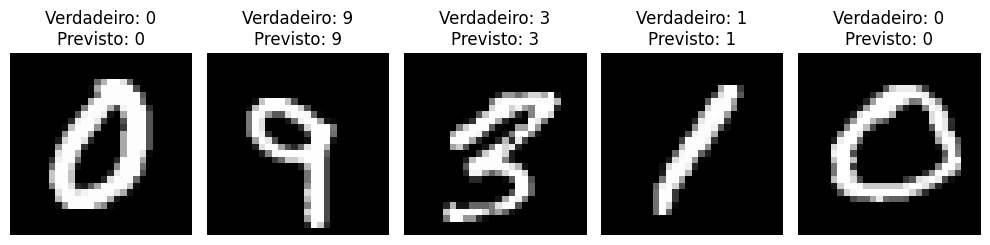

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Selecione um subconjunto aleatório dos dados de teste
num_images = 5
random_indices = np.random.choice(len(x_test), num_images, replace=False)
sample_images = x_test[random_indices]
sample_labels = y_test[random_indices]

# 2. Faça previsões nas imagens de amostra
predictions = model.predict(sample_images)

# 3. Obtenha as classes previstas (o índice com a maior probabilidade)
predicted_classes = np.argmax(predictions, axis=1)

# 4. Visualize as imagens e as previsões
plt.figure(figsize=(10, 4))
for i in range(num_images):
    plt.subplot(1, num_images, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    plt.title(f'Verdadeiro: {sample_labels[i]}\nPrevisto: {predicted_classes[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# LSTM - Exemplo previsão bolsa

A estrutura LSTM é bastante utilizada para previsão de preços de ativos financeiros. Por exemplo, usando dados de treinamento os preços de ações da empresa WEG do ano de 2023 pode-se prever os preços para os primeiros 6 meses do ano de 2024.

In [23]:
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense, Dropout, LSTM
import pandas as pd

In [22]:

base_treinamento = yf.download('WEGE3.SA', start="2023-01-01", end="2024-01-01", progress=False)['Close']
# Queremos remover eventuais valores nulos. Nessa base eles não são # muitos.
base_treinamento = base_treinamento.dropna()
#Vamos normalizar os valores para a faixa de 0 a 1. Isso ajuda no treinamento da rede.
normalizador = MinMaxScaler(feature_range=(0,1))
base_treinamento_normalizada = normalizador.fit_transform(base_treinamento)


/tmp/ipython-input-1276759740.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  base_treinamento = yf.download('WEGE3.SA', start="2023-01-01", end="2024-01-01", progress=False)['Close']


In [15]:
previsores = []
preco_real = []
# Variamos i a partir de 90, pois esse é o tamanho da janela que    # estamos observando.
for i in range(90, 248):
    previsores.append(base_treinamento_normalizada[i-90:i, 0])
    preco_real.append(base_treinamento_normalizada[i, 0])
# Transformamos os previsores e os preços reais em um array com formato correto para o treinamento na rede.
previsores, preco_real = np.array(previsores), np.array(preco_real)
previsores = np.reshape(previsores, (previsores.shape[0], previsores.shape[1], 1))

In [19]:
# Adicionamos também camadas de Dropout para prevenir ovefitting
regressor = Sequential()
regressor.add(LSTM(units = 100, return_sequences = True, input_shape = (previsores.shape[1], 1)))
regressor.add(Dropout(0.3))
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.3))
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.3))
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.3))
regressor.add(Dense(units = 1, activation = 'linear'))
# Aqui definimos o otimizador, a função de perda e métricas de      # avaliação do modelo durante o treinamento.
regressor.compile(optimizer = 'rmsprop', loss = 'mean_squared_error',
                  metrics = ['mean_absolute_error'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
# Por fim, damos início ao treinamento. A taxa de aprendizado foi a padrão do otimizador,0.001.
regressor.fit(previsores, preco_real, epochs = 150, batch_size = 32)

Epoch 1/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - loss: 0.1838 - mean_absolute_error: 0.3633
Epoch 2/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - loss: 0.0593 - mean_absolute_error: 0.1926
Epoch 3/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - loss: 0.0477 - mean_absolute_error: 0.1684
Epoch 4/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step - loss: 0.0375 - mean_absolute_error: 0.1441
Epoch 5/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - loss: 0.0424 - mean_absolute_error: 0.1616
Epoch 6/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 0.0372 - mean_absolute_error: 0.1519
Epoch 7/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - loss: 0.0498 - mean_absolute_error: 0.1750
Epoch 8/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step - loss: 0.0388 - mean_absolute_error: 0.1475
Epoch 9/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - loss: 0.0348 - mean_absolute_error: 0.1391
Epoch 10/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - loss: 0.0284 - mean_absolute_error: 0.1287
Epoch 11/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 2

In [24]:
base_teste = yf.download('WEGE3.SA', start="2024-01-01", end="2024-06-01", progress=False)['Close']
# Queremos remover eventuais valores nulos. Nessa base eles não são # muitos.
base_teste = base_teste.dropna()
#Vamos normalizar os valores para a faixa de 0 a 1. Isso ajuda no treinamento da rede.
normalizador = MinMaxScaler(feature_range=(0,1))
base_teste_normalizada = normalizador.fit_transform(base_teste)

# Precisamos das últimas 90 entradas dos dados de treino para começar os testes. Então concatenamos as duas bases.
base_completa = pd.concat((base_treinamento, base_teste), axis = 0)
# Agora extraímos da base completa apenas a porção que precisamos e # aplicamos o mesmo normalizador.
entradas = base_completa[(len(base_treinamento)  - 90):].values
entradas = entradas.reshape(-1, 1)
entradas = normalizador.transform(entradas)

# Aplicamos a mesma estruturação e antes, separando de 90 em 90     # dias, movendo um dia por vez.
X_teste = []
for i in range(90, len(entradas)): # Adjust the range to start from 90
    X_teste.append(entradas[i-90:i, 0])

X_teste = np.array(X_teste)
X_teste = np.reshape(X_teste, (X_teste.shape[0], X_teste.shape[1], 1)) # Now X_teste is 3D
previsoes = regressor.predict(X_teste)
previsoes = normalizador.inverse_transform(previsoes)

/tmp/ipython-input-1655182047.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  base_teste = yf.download('WEGE3.SA', start="2024-01-01", end="2024-06-01", progress=False)['Close']
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step


In [25]:
from sklearn.metrics import mean_absolute_error

# Ajuste o índice para corresponder ao número de previsões
real = base_teste.values[len(base_teste) - len(previsoes):]

# Cálculo do MAE
mae = mean_absolute_error(real, previsoes)
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 0.7367516664358286


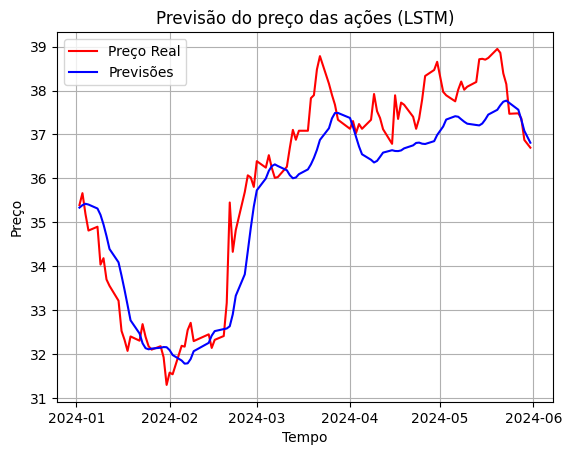

In [26]:
plt.plot(base_teste.index, base_teste.values, color='red', label='Preço Real')
plt.plot(base_teste.index, previsoes, color='blue', label='Previsões')
plt.title('Previsão do preço das ações (LSTM)')
plt.xlabel('Tempo')
plt.ylabel('Preço')
plt.legend()
plt.grid(True)  # Adiciona grades padrão
plt.savefig('prev_weg.png')
plt.show()